## Imports

Importation des bibliothèques nécessaires pour l'analyse de séries temporelles.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import scipy

## Chargement des données

Chargement du dataset maître traité.

In [5]:
import os

# Remonte au répertoire racine du projet
os.chdir('..')

df = pd.read_csv('data/processed/master_dataset.csv', parse_dates=['date'], index_col='date')
print(f"Shape: {df.shape}")
print(f"Période: {df.index.min()} à {df.index.max()}")
print(f"Colonnes: {list(df.columns)}")

Shape: (180, 10)
Période: 2010-01-01 00:00:00 à 2024-12-01 00:00:00
Colonnes: ['trends_composite', 'reddit_composite', 'youtube_composite', 'ipc_change', 'ipc', 'ipc_yoy', 'ipc_mom', 'besi', 'stress_level', 'besi_trends']


## Statistiques descriptives

Analyse descriptive de l'IPC et des indicateurs de stress.

In [7]:
print(df['ipc'].describe())

max_yoy = df['ipc_yoy'].max()
min_yoy = df['ipc_yoy'].min()
date_max = df['ipc_yoy'].idxmax()
date_min = df['ipc_yoy'].idxmin()
print(f"Inflation YoY max: {max_yoy:.2f}% le {date_max}")
print(f"Inflation YoY min: {min_yoy:.2f}% le {date_min}")

stress_dist = df['stress_level'].value_counts(normalize=True) * 100
print("Distribution des états de stress:")
print(stress_dist)

count    180.000000
mean       1.080312
std        0.073567
min        0.997789
25%        1.034141
50%        1.052078
75%        1.089324
max        1.243369
Name: ipc, dtype: float64
Inflation YoY max: 6.57% le 2022-03-01 00:00:00
Inflation YoY min: -0.25% le 2015-01-01 00:00:00
Distribution des états de stress:
stress_level
Normal         40.555556
Warning        34.444444
High Stress    25.000000
Name: proportion, dtype: float64


## Figure 1: Vue d'ensemble

Trois graphiques empilés montrant l'IPC, l'inflation YoY et le BESI avec seuils.

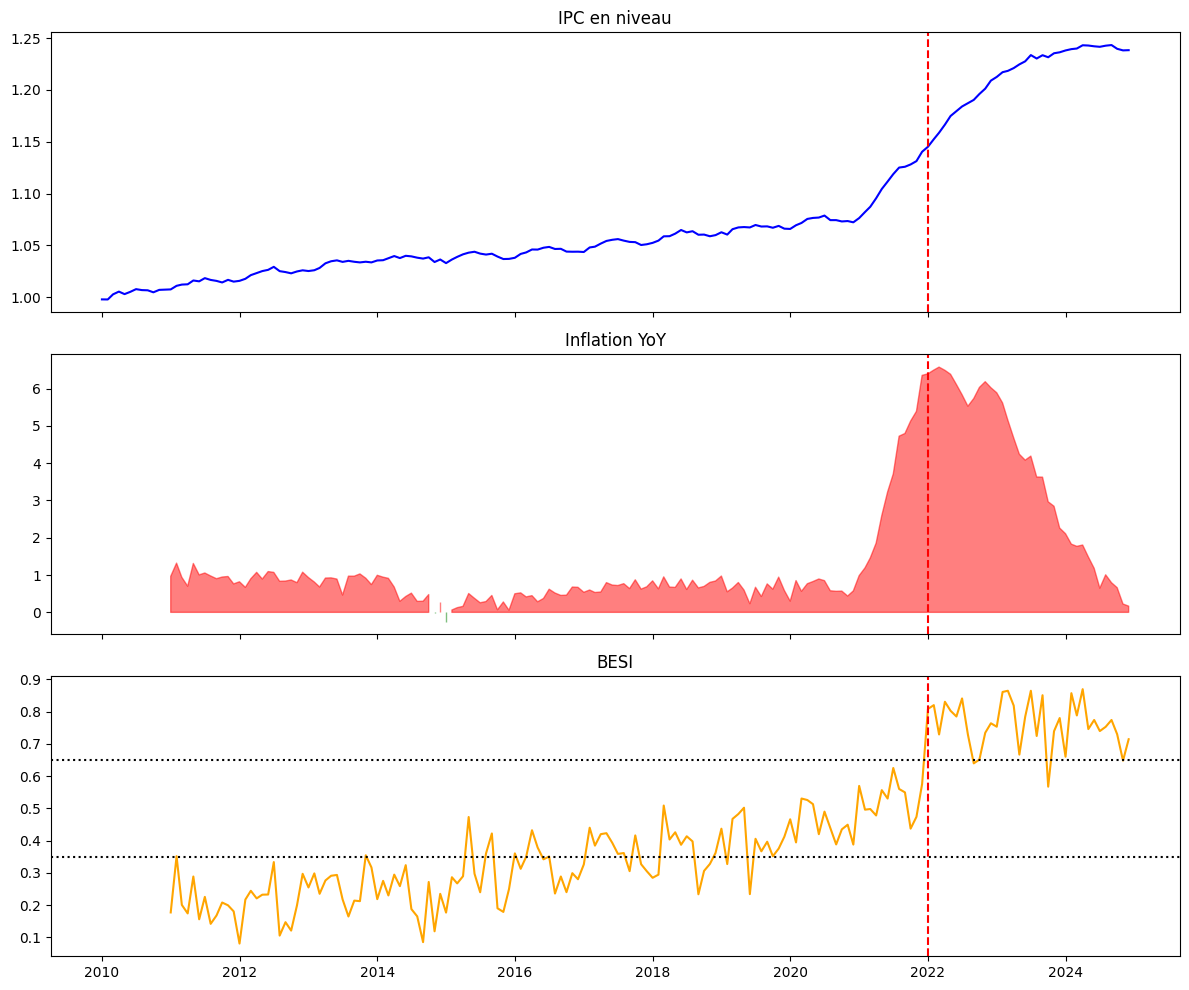

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# (a) IPC niveau
axes[0].plot(df.index, df['ipc'], color='blue')
axes[0].set_title('IPC en niveau')
axes[0].axvline(pd.Timestamp('2022-01-01'), color='red', linestyle='--')

# (b) ipc_yoy fill_between
axes[1].fill_between(df.index, df['ipc_yoy'], 0, where=(df['ipc_yoy'] >= 0), color='red', alpha=0.5)
axes[1].fill_between(df.index, df['ipc_yoy'], 0, where=(df['ipc_yoy'] < 0), color='green', alpha=0.5)
axes[1].set_title('Inflation YoY')
axes[1].axvline(pd.Timestamp('2022-01-01'), color='red', linestyle='--')

# (c) BESI
axes[2].plot(df.index, df['besi'], color='orange')
axes[2].axhline(0.35, color='black', linestyle=':', label='Seuil 0.35')
axes[2].axhline(0.65, color='black', linestyle=':', label='Seuil 0.65')
axes[2].set_title('BESI')
axes[2].axvline(pd.Timestamp('2022-01-01'), color='red', linestyle='--')

plt.tight_layout()
plt.savefig('outputs/figures/nb01_overview.png')
plt.show()

## Tests de stationnarité

Fonction pour tester la stationnarité avec ADF et KPSS.

In [11]:
def stationarity_test(series, name):
    # Nettoyer les NaN et inf
    clean_series = series.dropna()
    clean_series = clean_series[np.isfinite(clean_series)]
    
    if len(clean_series) < 10:
        return pd.DataFrame({
            'Serie': [name],
            'ADF stat': [np.nan],
            'ADF p': [np.nan],
            'KPSS stat': [np.nan],
            'KPSS p': [np.nan],
            'Decision': ['Données insuffisantes']
        })
    
    try:
        adf_result = adfuller(clean_series, autolag='AIC')
        kpss_result = kpss(clean_series, regression='c')
        decision = 'Stationnaire' if adf_result[1] < 0.05 and kpss_result[1] >= 0.05 else ('Non stationnaire' if adf_result[1] >= 0.05 and kpss_result[1] < 0.05 else 'Ambigu')
    except Exception as e:
        return pd.DataFrame({
            'Serie': [name],
            'ADF stat': [np.nan],
            'ADF p': [np.nan],
            'KPSS stat': [np.nan],
            'KPSS p': [np.nan],
            'Decision': [f'Erreur: {str(e)[:30]}']
        })
    
    return pd.DataFrame({
        'Serie': [name],
        'ADF stat': [adf_result[0]],
        'ADF p': [adf_result[1]],
        'KPSS stat': [kpss_result[0]],
        'KPSS p': [kpss_result[1]],
        'Decision': [decision]
    })

tests = []
tests.append(stationarity_test(df['ipc'].dropna(), 'ipc niveau'))
tests.append(stationarity_test(df['ipc'].diff(1), 'ipc diff(1)'))
tests.append(stationarity_test(df['ipc'].diff(1).diff(1), 'ipc diff(1).diff(1)'))
tests.append(stationarity_test(df['ipc_yoy'].dropna(), 'ipc_yoy'))
tests.append(stationarity_test(df['besi'].dropna(), 'besi niveau'))
tests.append(stationarity_test(df['besi'].diff(1), 'besi diff(1)'))

results = pd.concat(tests, ignore_index=True)
print(results.to_string())
print("\nNote: Stationnaire si ADF p < 0.05 et KPSS p >= 0.05. Non stationnaire sinon. Ambigu si contradiction.")

C:\Users\basse\AppData\Local\Temp\ipykernel_8952\650984493.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(clean_series, regression='c')
C:\Users\basse\AppData\Local\Temp\ipykernel_8952\650984493.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(clean_series, regression='c')
C:\Users\basse\AppData\Local\Temp\ipykernel_8952\650984493.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(clean_series, regression='c')
C:\Users\basse\AppData\Local\Temp\ipykernel_8952\650984493.py:18: InterpolationWarning: The test statistic is outside of the range of p-values avail

                 Serie  ADF stat         ADF p  KPSS stat    KPSS p          Decision
0           ipc niveau -1.835725  3.628750e-01   1.522117  0.010000  Non stationnaire
1          ipc diff(1) -1.797179  3.818632e-01   0.582322  0.024243  Non stationnaire
2  ipc diff(1).diff(1) -8.809953  2.003830e-14   0.082396  0.100000      Stationnaire
3              ipc_yoy -2.320327  1.654960e-01   0.754457  0.010000  Non stationnaire
4          besi niveau -0.145929  9.446673e-01   1.733445  0.010000  Non stationnaire
5         besi diff(1) -3.838073  2.540938e-03   0.154448  0.100000      Stationnaire

Note: Stationnaire si ADF p < 0.05 et KPSS p >= 0.05. Non stationnaire sinon. Ambigu si contradiction.


## Décomposition STL

Décomposition saisonnière-trend-résidu de l'IPC.

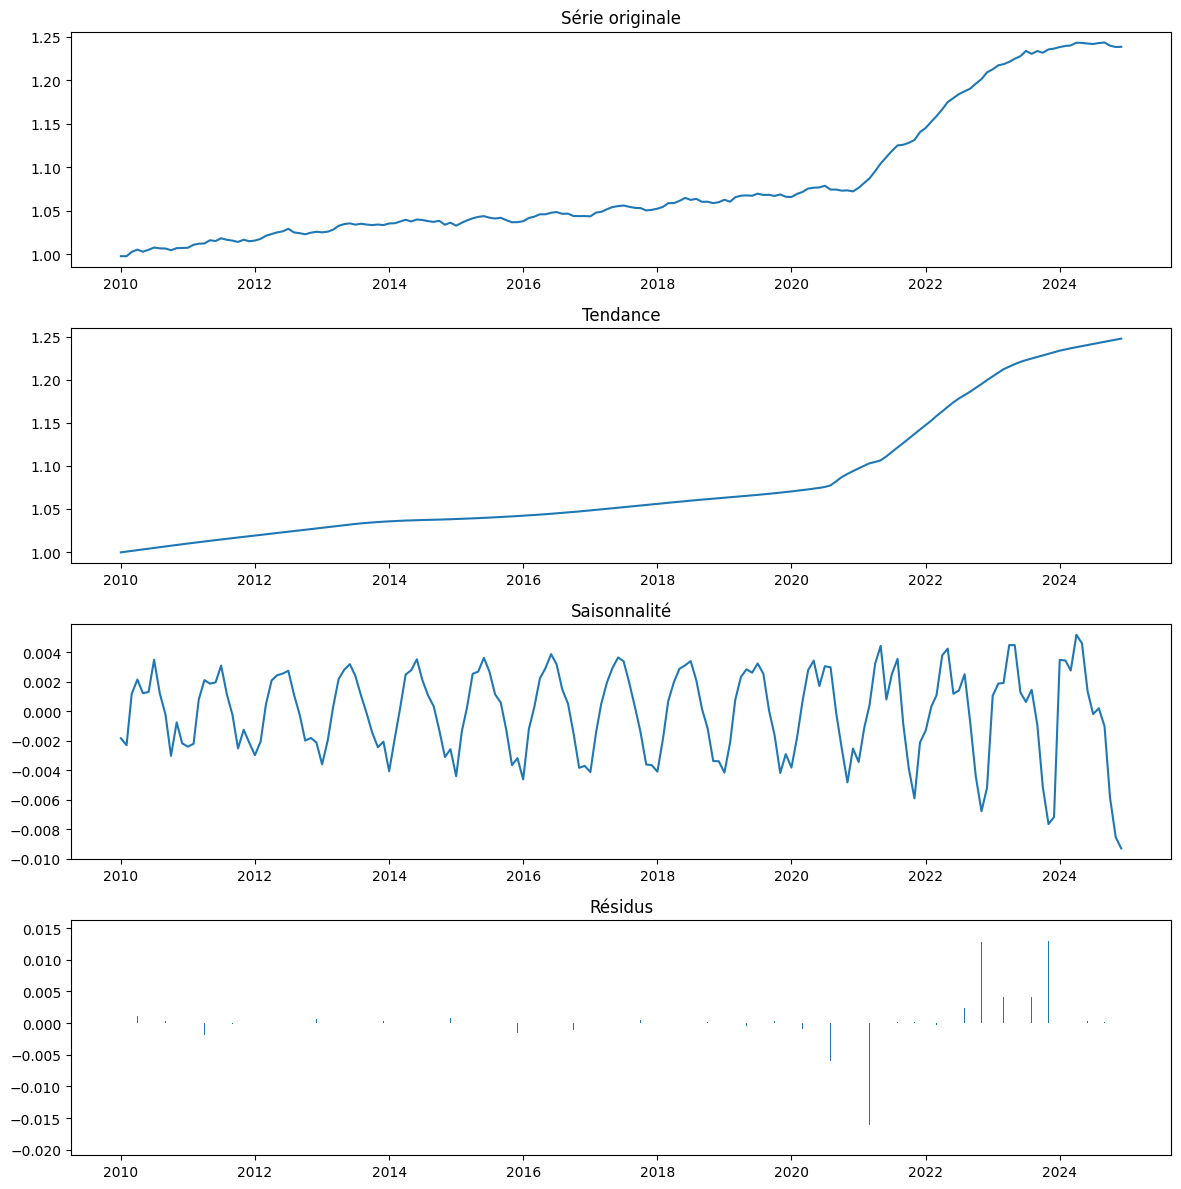

In [12]:
stl = STL(df['ipc'], period=12, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 12))

axes[0].plot(df.index, result.observed)
axes[0].set_title('Série originale')

axes[1].plot(df.index, result.trend)
axes[1].set_title('Tendance')

axes[2].plot(df.index, result.seasonal)
axes[2].set_title('Saisonnalité')

axes[3].bar(df.index, result.resid)
axes[3].set_title('Résidus')

plt.tight_layout()
plt.savefig('outputs/figures/nb01_stl.png')
plt.show()

## ACF/PACF

Analyse des autocorrélations pour identifier les ordres SARIMA.

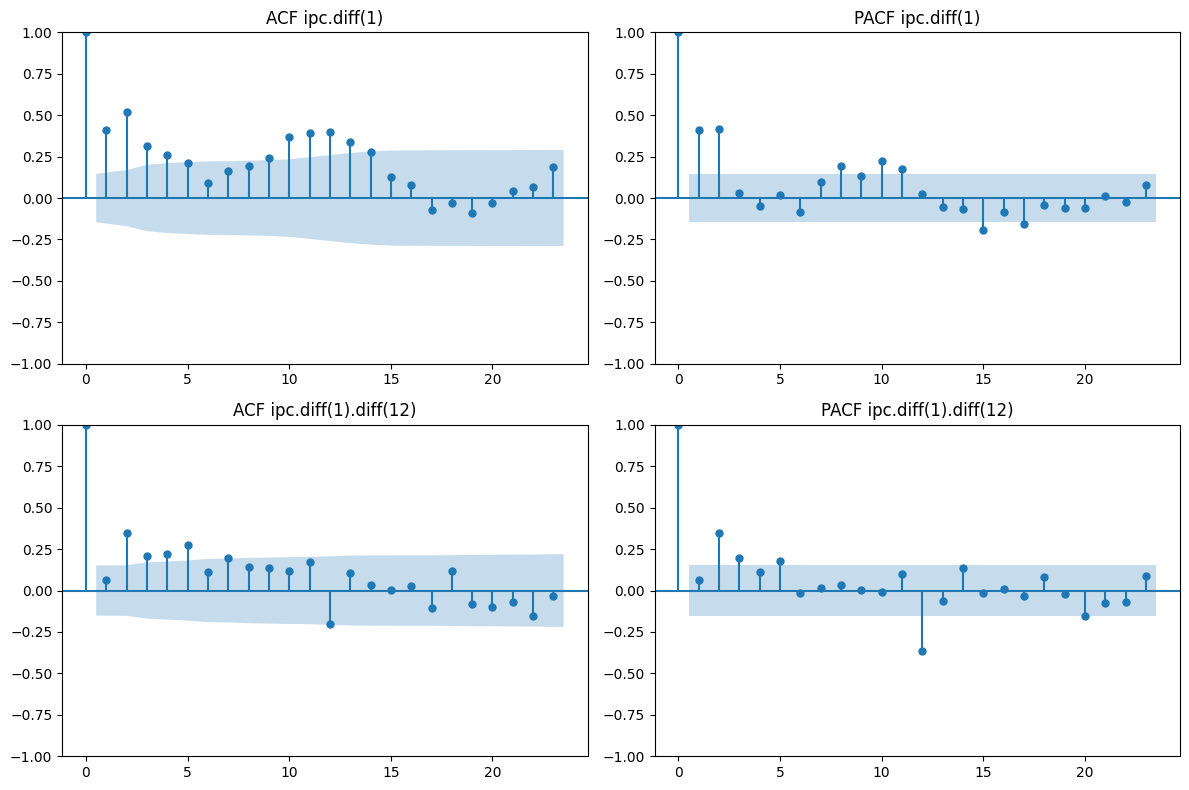

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plot_acf(df['ipc'].diff(1).dropna(), ax=axes[0,0], title='ACF ipc.diff(1)')
plot_pacf(df['ipc'].diff(1).dropna(), ax=axes[0,1], title='PACF ipc.diff(1)')
plot_acf(df['ipc'].diff(1).diff(12).dropna(), ax=axes[1,0], title='ACF ipc.diff(1).diff(12)')
plot_pacf(df['ipc'].diff(1).diff(12).dropna(), ax=axes[1,1], title='PACF ipc.diff(1).diff(12)')

plt.tight_layout()
plt.savefig('outputs/figures/nb01_acf_pacf.png')
plt.show()

### Explication ACF/PACF

ACF lag 1 significatif -> q=1  
PACF lags 1-2 significatifs -> p=2  
ACF lag 12 significatif -> Q=1  
Candidat SARIMA(2,1,1)x(0,1,1)[12]

## Composantes BESI

Évolution des composantes du BESI.

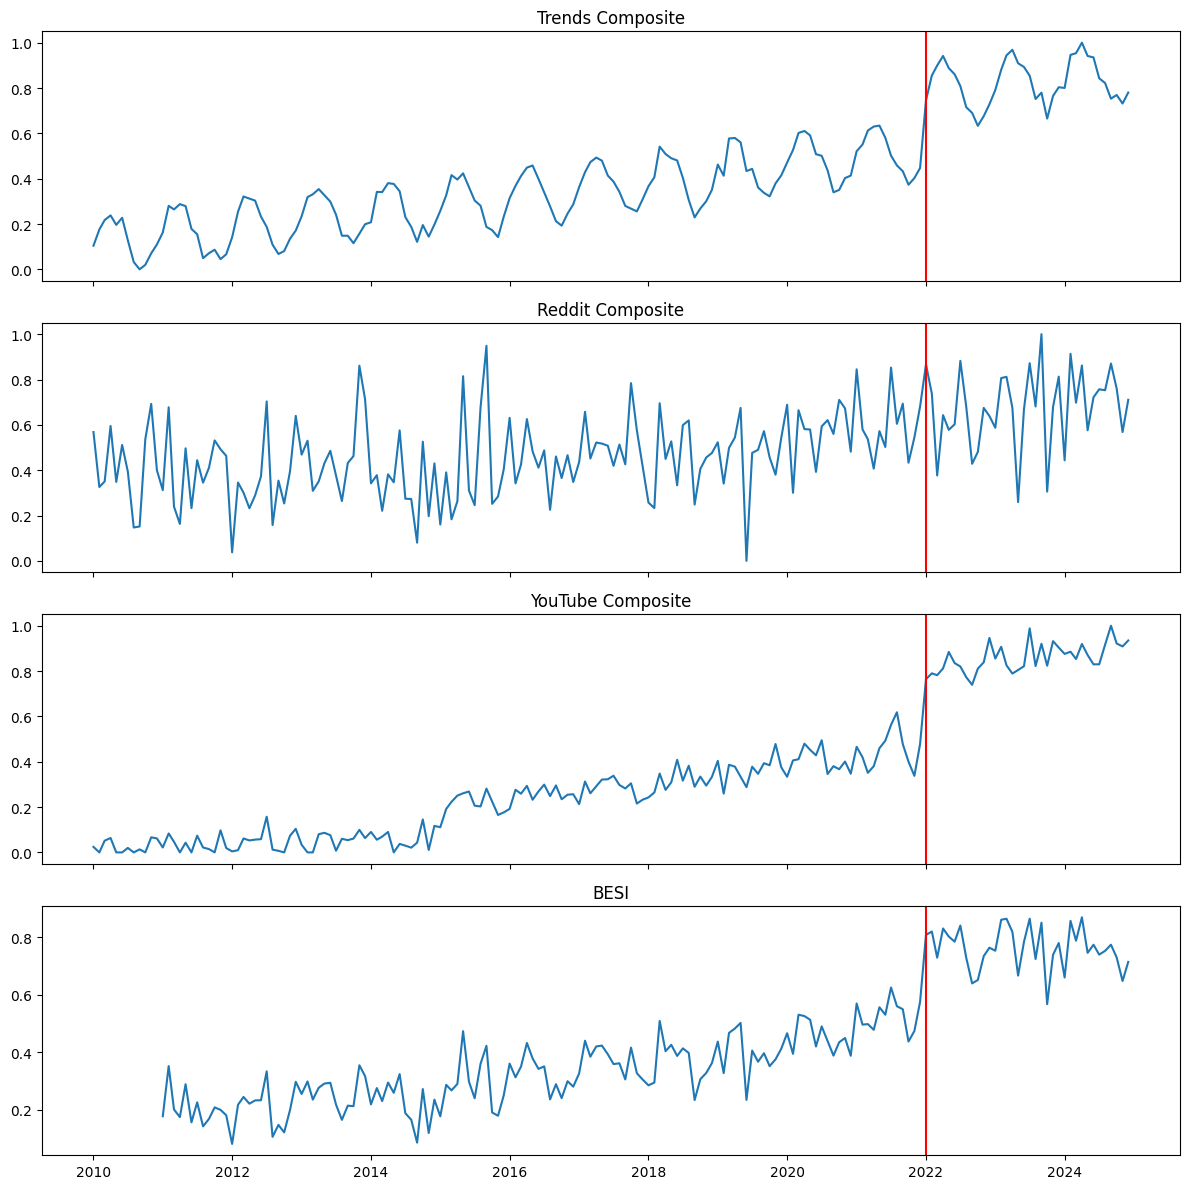

In [14]:
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

axes[0].plot(df.index, df['trends_composite'])
axes[0].set_title('Trends Composite')
axes[0].axvline(pd.Timestamp('2022-01-01'), color='red')

axes[1].plot(df.index, df['reddit_composite'])
axes[1].set_title('Reddit Composite')
axes[1].axvline(pd.Timestamp('2022-01-01'), color='red')

axes[2].plot(df.index, df['youtube_composite'])
axes[2].set_title('YouTube Composite')
axes[2].axvline(pd.Timestamp('2022-01-01'), color='red')

axes[3].plot(df.index, df['besi'])
axes[3].set_title('BESI')
axes[3].axvline(pd.Timestamp('2022-01-01'), color='red')

plt.tight_layout()
plt.savefig('outputs/figures/nb01_besi_components.png')
plt.show()